# JO 2028 - Machine Learning Pipeline
## Prédictions des médailles olympiques avec XGBoost
**Équipe:** Mathéo Morival & Imane Guarraz | Ynov B3

---

## 1. IMPORTS ET CONFIGURATION

### 1.1 Objectif de cette étape
Dans cette partie, on charge toutes les bibliothèques nécessaires au pipeline ML.
On sépare les imports de la configuration pour rendre le flux plus lisible.

In [23]:
# --- Imports de base pour la manipulation de données ---
import pandas as pd  # Tableaux de données
import numpy as np  # Calcul numérique

# --- Imports de visualisation ---
import matplotlib.pyplot as plt  # Graphiques Matplotlib
import seaborn as sns  # Graphiques statistiques

# --- Imports de préparation et modélisation ---
from sklearn.model_selection import train_test_split  # Découpage train/test
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Normalisation et encodage
from sklearn.decomposition import PCA  # Réduction de dimension (si nécessaire)
from sklearn.ensemble import RandomForestClassifier  # Modèle de référence possible
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve  # Métriques
from xgboost import XGBClassifier  # Modèle principal

# --- Imports utilitaires ---
import warnings  # Gestion des warnings
import os  # Gestion des chemins et dossiers

### 1.2 Configuration de l'environnement
On applique les réglages visuels et notebook (style, palette, affichage inline).
Ces paramètres n'impactent pas le modèle, seulement la lisibilité et le confort de travail.

In [24]:
# Désactiver les warnings non bloquants pour garder une sortie claire
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')  # Style visuel global
sns.set_palette('husl')  # Palette par défaut
%matplotlib inline

print("✓ Toutes les bibliothèques et configurations sont prêtes")

✓ Toutes les bibliothèques et configurations sont prêtes


## 2. CHARGEMENT DES DONNÉES

### 2.1 Définition des chemins et lecture des fichiers
On prépare les chemins d'accès aux données brutes et au dossier de sortie.
Ensuite, on charge les deux fichiers CSV nécessaires au projet.

In [25]:
# Chemins d'entrée/sortie
data_path = "./data/data brut/"  # Dossier des données sources
clean_path = "./data/data clean/"  # Dossier des sorties nettoyées

# Créer le dossier de sortie s'il n'existe pas
os.makedirs(clean_path, exist_ok=True)

print("Chargement des données...")

# Charger le dataset principal (séparateur ';')
df_main = pd.read_csv(
    os.path.join(data_path, "olympics_dataset.csv"),
    sep=";",
    low_memory=False
 )

# Charger le dataset des âges
df_age = pd.read_csv(
    os.path.join(data_path, "olympics_age.csv"),
    low_memory=False
 )

Chargement des données...


### 2.2 Harmonisation des colonnes et contrôle visuel
On aligne les noms de colonnes du fichier d'âges avec le dataset principal.
On termine par un contrôle de forme, de colonnes et un aperçu des premières lignes.

In [26]:
# Harmoniser les colonnes du fichier âge pour éviter les erreurs de merge
if "name" in df_age.columns:
    df_age = df_age.rename(columns={"name": "Name"})  # Uniformiser le nom de colonne

if "age" in df_age.columns:
    df_age = df_age.rename(columns={"age": "Age"})  # Uniformiser le nom de colonne

# Vérifier la structure des jeux de données
print(f"✓ Dataset principal: {df_main.shape}")
print(f"✓ Dataset âges: {df_age.shape}")

# Afficher les colonnes disponibles
print(f"\nColonnes dataset principal: {df_main.columns.tolist()}")
print(f"Colonnes dataset âges: {df_age.columns.tolist()}")

# Afficher les premières lignes du dataset principal
print("\nPremières lignes du dataset principal:")
print(df_main.head())

✓ Dataset principal: (252565, 11)
✓ Dataset âges: (300714, 8)

Colonnes dataset principal: ['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']
Colonnes dataset âges: ['Name', 'sex', 'Age', 'medal', 'year', 'season', 'noc', 'country']

Premières lignes du dataset principal:
   player_id                   Name Sex            Team  NOC  Year  Season  \
0          0              A Dijiang   M           China  CHN  1992  Summer   
1          1               A Lamusi   M           China  CHN  2012  Summer   
2          2            Gunnar Aaby   M         Denmark  DEN  1920  Summer   
3          3            Edgar Aabye   M  Denmark/Sweden  DEN  1900  Summer   
4         26  Cornelia (-strannood)   F     Netherlands  NED  1932  Summer   

          City       Sport                         Event     Medal  
0    Barcelona  Basketball   Basketball Men's Basketball  No medal  
1       London        Judo  Judo Men's Extra-Lightweight  No medal  
2    

## 3. PRÉPARATION ET NETTOYAGE

In [27]:
# Diagnostic initial avant nettoyage
print("AVANT nettoyage:")
print(f"  Lignes: {len(df_main)}")
print(f"  Valeurs nulles: {df_main.isna().sum().sum()}")
print(f"  Colonnes: {df_main.columns.tolist()}")

# Créer une copie de travail pour préserver la donnée source
df = df_main.copy()

# Supprimer les colonnes non utiles au périmètre de l'étude
if 'Season' in df.columns:
    df = df.drop('Season', axis=1)  # Colonne redondante ici (JO d'été ciblés)
    print("  ✓ Colonne 'Season' supprimée")

AVANT nettoyage:
  Lignes: 252565
  Valeurs nulles: 0
  Colonnes: ['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']
  ✓ Colonne 'Season' supprimée


### 3.1 Fusion des âges par clé robuste (NOC, année, sexe)
On construit une clé de rapprochement stable pour retrouver l'âge médian par groupe.
Cette méthode est plus fiable qu'un matching direct sur les noms.

In [28]:
# Préparer une table auxiliaire d'âges
age_aux = df_age.copy()
age_aux['Age'] = pd.to_numeric(age_aux['Age'], errors='coerce')
age_aux['year'] = pd.to_numeric(age_aux.get('year'), errors='coerce')
age_aux['noc'] = age_aux.get('noc', pd.Series(index=age_aux.index, dtype='object')).astype(str).str.upper().str.strip()
age_aux['sex'] = age_aux.get('sex', pd.Series(index=age_aux.index, dtype='object')).astype(str).str.strip()

# Agréger l'âge médian par (pays, année, sexe)
age_group = (
    age_aux.dropna(subset=['Age', 'year'])
    .groupby(['noc', 'year', 'sex'], as_index=False)['Age']
    .median()
    .rename(columns={'noc': 'NOCKey', 'year': 'YearKey', 'sex': 'SexKey', 'Age': 'Age_group'})
)

# Construire les clés côté dataset principal
df['NOCKey'] = df['NOC'].astype(str).str.upper().str.strip()
df['YearKey'] = pd.to_numeric(df['Year'], errors='coerce')
df['SexKey'] = df['Sex'].map({'M': 'Male', 'F': 'Female'}).fillna(df['Sex'])

# Fusionner et initialiser la colonne Age
df = df.merge(age_group, on=['NOCKey', 'YearKey', 'SexKey'], how='left')
df['Age'] = df['Age_group']

### 3.2 Fallback par nom et imputation finale
Quand la fusion par clé ne trouve pas d'âge, on tente un matching par nom normalisé.
Enfin, on impute les valeurs restantes pour éviter de perdre des observations.

In [29]:
# Fonction utilitaire: normaliser les noms pour le matching tolérant
def normalize_name(s):
    return (
        s.astype(str)
        .str.lower()  # Uniformiser la casse
        .str.strip()  # Supprimer espaces en début/fin
        .str.replace(r"[^a-z0-9]", "", regex=True)  # Retirer ponctuation et caractères spéciaux
    )

# Construire une table âge par nom normalisé
name_aux = df_age[['Name', 'Age']].copy()
name_aux['Age'] = pd.to_numeric(name_aux['Age'], errors='coerce')
name_aux = name_aux.dropna(subset=['Name', 'Age'])
name_aux['name_key'] = normalize_name(name_aux['Name'])
age_by_name = name_aux.groupby('name_key')['Age'].median()

# Préparer des clés nom dans df
df['name_key'] = normalize_name(df['Name'])
df['name_key_drop1'] = normalize_name(df['Name'].str[1:])  # Tolérance à un caractère parasite initial

# Remplir d'abord par clé nominale stricte
missing_age_mask = df['Age'].isna()
df.loc[missing_age_mask, 'Age'] = df.loc[missing_age_mask, 'name_key'].map(age_by_name)

# Puis par clé tolérante (nom tronqué)
missing_age_mask = df['Age'].isna()
df.loc[missing_age_mask, 'Age'] = df.loc[missing_age_mask, 'name_key_drop1'].map(age_by_name)

# Imputer les âges restants par médiane du sport, puis médiane globale
sport_age_median = df.groupby('Sport')['Age'].transform('median')
df['Age'] = df['Age'].fillna(sport_age_median)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Mesurer le taux de matching direct par groupe
matching_rate_group = df['Age_group'].notna().mean() * 100
print(f"  ✓ Âges fusionnés (matching NOC/Year/Sex: {matching_rate_group:.1f}%)")

  ✓ Âges fusionnés (matching NOC/Year/Sex: 99.9%)


### 3.3 Filtres métier, création de la cible et nettoyage final
On applique les filtres de cohérence (âge et période), puis on crée la cible binaire has_medal.
On supprime enfin les colonnes techniques utilisées uniquement pendant le nettoyage.

In [30]:
# Filtrer les anomalies d'âge et de période
df = df[(df['Age'] >= 14) & (df['Age'] <= 45)].copy()
df = df[df['Year'] >= 1960].copy()
print("  ✓ Filtres appliqués (Age 14-45, Year >= 1960)")

# Créer la cible binaire has_medal
df['Medal'] = df['Medal'].fillna('No medal').astype(str).str.strip()
df['has_medal'] = (df['Medal'].str.lower() != 'no medal').astype(int)
print(f"  ✓ Target créée (médaillés: {df['has_medal'].sum()} / {len(df)})")
print(f"    Taux de médaillés: {df['has_medal'].mean():.2%}")

# Supprimer les colonnes techniques utilisées pour le matching
df = df.drop(
    columns=['NOCKey', 'YearKey', 'SexKey', 'Age_group', 'name_key', 'name_key_drop1'],
    errors='ignore'
)

# Diagnostic final
print(f"\nAPRÈS nettoyage:")
print(f"  Lignes: {len(df)}")
print(f"  Valeurs nulles: {df.isna().sum().sum()}")
print(f"  Colonnes: {df.columns.tolist()}")

  ✓ Filtres appliqués (Age 14-45, Year >= 1960)
  ✓ Target créée (médaillés: 28275 / 196266)
    Taux de médaillés: 14.41%

APRÈS nettoyage:
  Lignes: 196266
  Valeurs nulles: 0
  Colonnes: ['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport', 'Event', 'Medal', 'Age', 'has_medal']


## 4. ANALYSE EXPLORATOIRE UNIVARIÉE

### 4.1 Statistiques descriptives de base
On commence par des indicateurs simples pour comprendre la distribution des variables clés.
Cette étape sert de base avant les visualisations.

In [31]:
# Résumé statistique des variables numériques principales
print("Statistiques descriptives:")
print(df[['Year', 'Age']].describe())

# Distribution de la variable cible
print(f"\nDistribution de la target:")
print(df['has_medal'].value_counts())
print(f"  Taux de médaille: {df['has_medal'].mean():.2%}")

# Pays les plus représentés
print(f"\nTop 10 pays (par nombre de participations):")
print(df['NOC'].value_counts().head(10))

# Sports les plus représentés
print(f"\nTop 10 sports:")
print(df['Sport'].value_counts().head(10))

Statistiques descriptives:
                Year            Age
count  196266.000000  196266.000000
mean     1996.054171      24.499322
std        19.008414       2.219658
min      1960.000000      14.000000
25%      1980.000000      23.500000
50%      1996.000000      25.000000
75%      2012.000000      26.000000
max      2024.000000      44.000000

Distribution de la target:
has_medal
0    167991
1     28275
Name: count, dtype: int64
  Taux de médaille: 14.41%

Top 10 pays (par nombre de participations):
NOC
USA    10933
AUS     7520
GBR     7454
FRA     7108
ITA     6724
JPN     6715
CAN     6496
GER     6189
CHN     5383
ESP     5336
Name: count, dtype: int64

Top 10 sports:
Sport
Athletics     32759
Swimming      23220
Gymnastics    18179
Rowing         8879
Shooting       8458
Cycling        7917
Fencing        7171
Football       6011
Wrestling      5779
Sailing        5719
Name: count, dtype: int64


### Visualisations univariées

### 4.2 Visualisations univariées détaillées
On construit 4 graphiques pour lire séparément les distributions d'année, d'âge, de médaille et de sexe.
Chaque graphe est annoté pour faciliter l'interprétation directe.

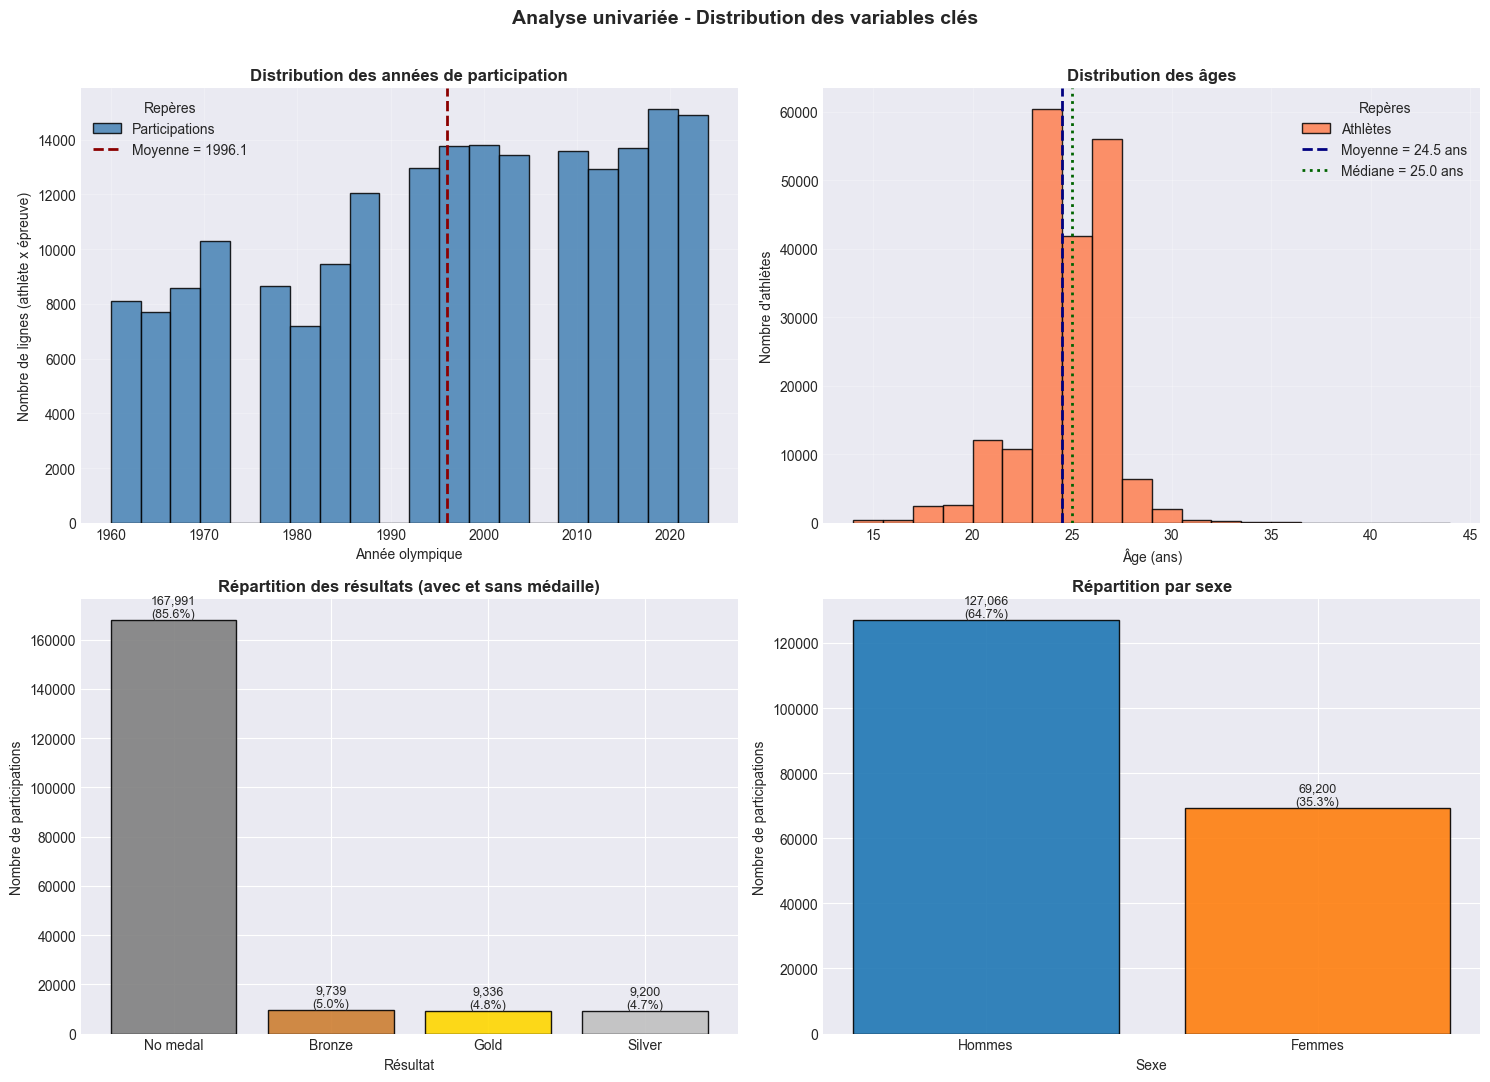

✓ Visualisations univariées détaillées générées


In [32]:
# ======================================================================
# CELLULE DE VISUALISATION UNIVARIÉE (4 GRAPHIQUES)
# Objectif: lire séparément la distribution de chaque variable clé.
# ======================================================================

# Créer une figure avec 2 lignes x 2 colonnes de sous-graphiques.
# figsize contrôle la taille globale pour que les labels restent lisibles.
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Ajouter un titre général à la figure complète.
# Il sert de contexte global quand on exporte/capture le visuel.
fig.suptitle("Analyse univariée - Distribution des variables clés", fontsize=14, fontweight='bold')

# Conserver le nombre total d'observations.
# Cette valeur sera utilisée pour calculer les pourcentages affichés sur les barres.
n_total = len(df)

# ----------------------------------------------------------------------
# 1) Distribution des années olympiques
# ----------------------------------------------------------------------

# Calculer la moyenne des années observées pour créer un repère visuel.
year_mean = df['Year'].mean()

# Tracer un histogramme de la variable Year.
# bins=20: compromis entre détail et lisibilité.
# alpha: transparence légère pour adoucir le rendu.
axes[0, 0].hist(
    df['Year'],
    bins=20,
    color='steelblue',
    edgecolor='black',
    alpha=0.85,
    label='Participations'
 )

# Ajouter une ligne verticale de moyenne pour faciliter l'interprétation.
axes[0, 0].axvline(
    year_mean,
    color='darkred',
    linestyle='--',
    linewidth=2,
    label=f'Moyenne = {year_mean:.1f}'
 )

# Titrer et nommer les axes pour rendre le graphe auto-portant.
axes[0, 0].set_title('Distribution des années de participation', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Année olympique')
axes[0, 0].set_ylabel('Nombre de lignes (athlète x épreuve)')

# Afficher une légende et une grille légère pour mieux lire les valeurs.
axes[0, 0].legend(title='Repères', loc='upper left')
axes[0, 0].grid(True, alpha=0.25)

# ----------------------------------------------------------------------
# 2) Distribution des âges
# ----------------------------------------------------------------------

# Calculer moyenne et médiane de l'âge.
# Les deux sont affichées car elles racontent des choses complémentaires.
age_mean = df['Age'].mean()
age_median = df['Age'].median()

# Tracer l'histogramme des âges.
# dropna évite d'inclure des valeurs manquantes dans les bins.
axes[0, 1].hist(
    df['Age'].dropna(),
    bins=20,
    color='coral',
    edgecolor='black',
    alpha=0.85,
    label='Athlètes'
 )

# Ajouter repère de moyenne.
axes[0, 1].axvline(age_mean, color='navy', linestyle='--', linewidth=2, label=f'Moyenne = {age_mean:.1f} ans')

# Ajouter repère de médiane.
axes[0, 1].axvline(age_median, color='darkgreen', linestyle=':', linewidth=2, label=f'Médiane = {age_median:.1f} ans')

# Habiller le graphe.
axes[0, 1].set_title('Distribution des âges', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Âge (ans)')
axes[0, 1].set_ylabel("Nombre d'athlètes")
axes[0, 1].legend(title='Repères', loc='upper right')
axes[0, 1].grid(True, alpha=0.25)

# ----------------------------------------------------------------------
# 3) Répartition des résultats (No medal / Bronze / Silver / Gold)
# ----------------------------------------------------------------------

# Compter les occurrences de chaque catégorie de médaille.
medals = df['Medal'].value_counts(dropna=False)

# Convertir l'index en texte pour garantir une gestion homogène des labels.
medal_labels = medals.index.astype(str)

# Définir une couleur par type de résultat pour rendre la lecture intuitive.
medal_colors = [
    '#808080' if m.lower() == 'no medal'
    else '#CD7F32' if m.lower() == 'bronze'
    else '#C0C0C0' if m.lower() == 'silver'
    else '#FFD700'
    for m in medal_labels
 ]

# Tracer le barplot des catégories de résultat.
axes[1, 0].bar(medal_labels, medals.values, color=medal_colors, edgecolor='black', alpha=0.9)

# Habiller le graphe.
axes[1, 0].set_title('Répartition des résultats (avec et sans médaille)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Résultat')
axes[1, 0].set_ylabel('Nombre de participations')

# Annoter chaque barre en volume + pourcentage.
for i, val in enumerate(medals.values):
    pct = 100 * val / n_total
    axes[1, 0].text(i, val, f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# ----------------------------------------------------------------------
# 4) Répartition par sexe
# ----------------------------------------------------------------------

# Compter les observations par sexe.
gender = df['Sex'].value_counts()

# Fixer un ordre d'affichage stable.
gender_order = ['M', 'F']
gender = gender.reindex([g for g in gender_order if g in gender.index])

# Transformer les codes en libellés métier.
gender_labels = ['Hommes' if g == 'M' else 'Femmes' for g in gender.index]

# Tracer le barplot sexe.
axes[1, 1].bar(
    gender_labels,
    gender.values,
    color=['#1f77b4', '#ff7f0e'][:len(gender)],
    edgecolor='black',
    alpha=0.9
 )

# Habiller le graphe.
axes[1, 1].set_title('Répartition par sexe', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sexe')
axes[1, 1].set_ylabel('Nombre de participations')

# Annoter chaque barre avec volume et part relative.
for i, val in enumerate(gender.values):
    pct = 100 * val / n_total
    axes[1, 1].text(i, val, f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# Ajuster automatiquement les marges pour éviter le chevauchement des labels.
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Afficher la figure.
plt.show()

# Message de fin pour signaler que le bloc graphique est terminé.
print("✓ Visualisations univariées détaillées générées")

## 5. ANALYSE EXPLORATOIRE BIVARIÉE

### 5.1 Relations entre variables et médaille
Cette section compare la cible has_medal avec les variables principales.
On mélange courbes, boxplot et barplots pour une lecture multi-angle.

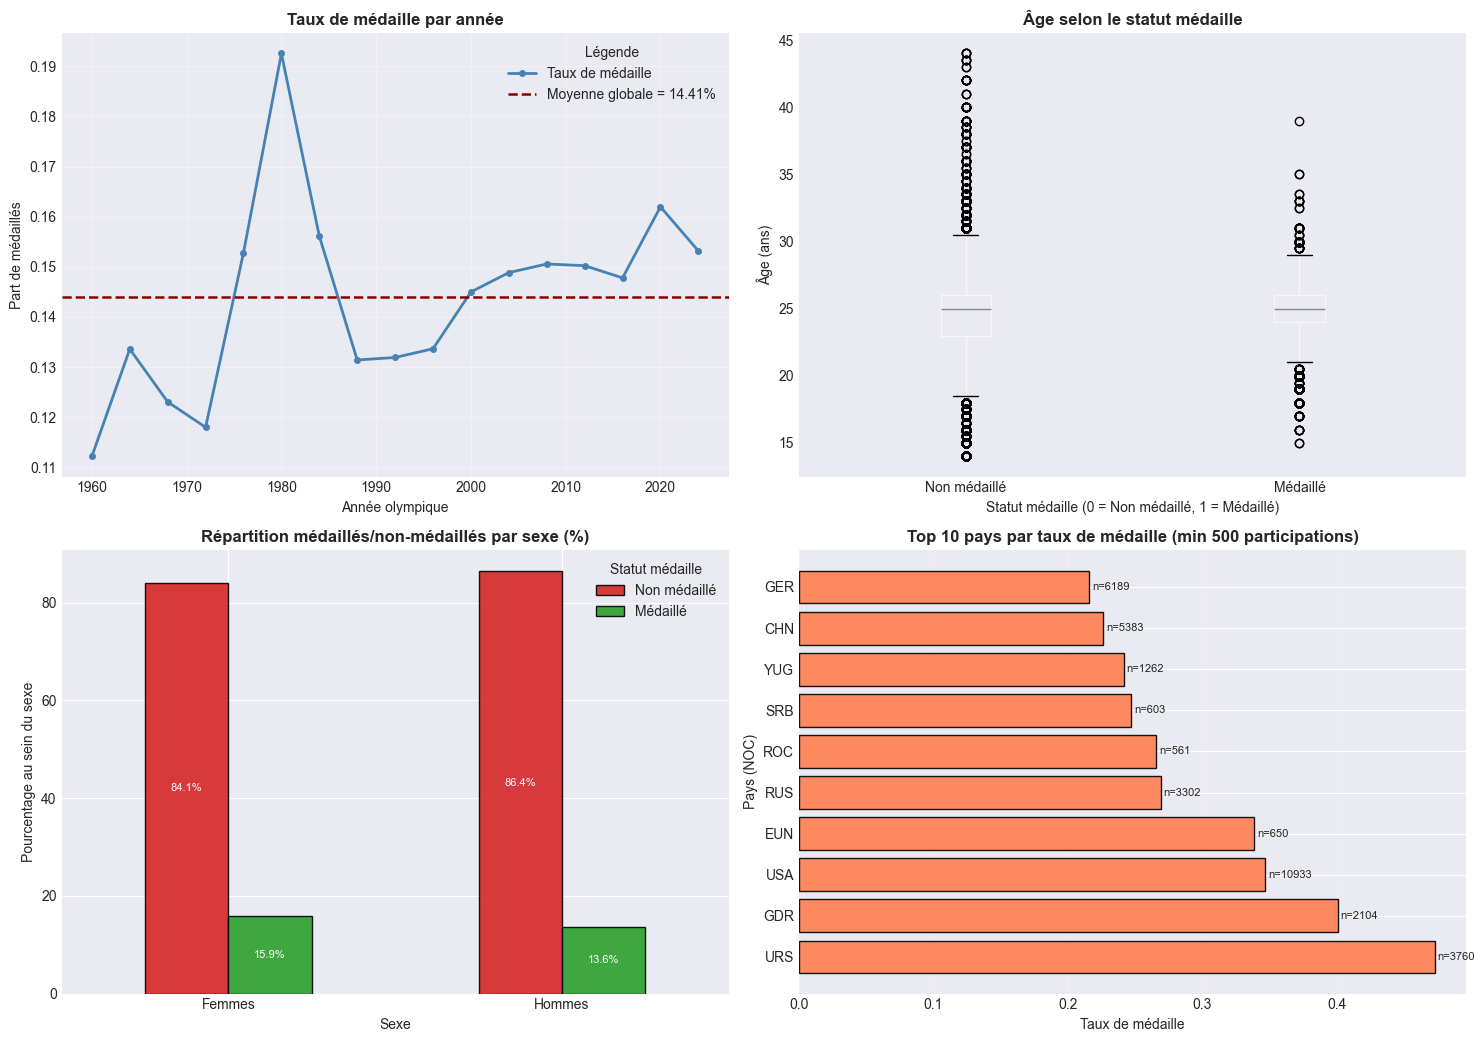

✓ Analyses bivariées détaillées affichées


In [33]:
# ======================================================================
# CELLULE DE VISUALISATION BIVARIÉE (relation avec has_medal)
# Objectif: montrer comment la cible varie selon année, âge, sexe et pays.
# ======================================================================

# Créer une figure 2x2 pour comparer plusieurs angles d'analyse sur une même page.
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Analyse bivariée - Relations avec la médaille", fontsize=14, fontweight='bold')

# ----------------------------------------------------------------------
# 1) Taux de médaille par année
# ----------------------------------------------------------------------

# Agréger la cible binaire par année: moyenne = taux de médaillés.
medal_by_year = df.groupby('Year')['has_medal'].mean()

# Tracer l'évolution temporelle du taux.
axes[0, 0].plot(
    medal_by_year.index,
    medal_by_year.values,
    color='steelblue',
    linewidth=2,
    marker='o',
    markersize=4,
    label='Taux de médaille'
 )

# Ajouter la moyenne globale comme baseline de comparaison.
axes[0, 0].axhline(
    df['has_medal'].mean(),
    color='darkred',
    linestyle='--',
    linewidth=1.8,
    label=f"Moyenne globale = {df['has_medal'].mean():.2%}"
 )

# Habillage du sous-graphe.
axes[0, 0].set_title('Taux de médaille par année', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Année olympique')
axes[0, 0].set_ylabel('Part de médaillés')
axes[0, 0].legend(title='Légende', loc='best')
axes[0, 0].grid(True, alpha=0.3)

# ----------------------------------------------------------------------
# 2) Distribution de l'âge selon statut médaille
# ----------------------------------------------------------------------

# Utiliser un boxplot pour comparer médianes et dispersion de l'âge selon has_medal.
df.boxplot(column='Age', by='has_medal', ax=axes[0, 1], grid=False)

# Habillage.
axes[0, 1].set_title('Âge selon le statut médaille', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Statut médaille (0 = Non médaillé, 1 = Médaillé)')
axes[0, 1].set_ylabel('Âge (ans)')

# Remplacer les ticks techniques 1/2 par des libellés lisibles.
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['Non médaillé', 'Médaillé'])

# Supprimer le suptitle automatique ajouté par pandas.boxplot.
plt.suptitle('')

# ----------------------------------------------------------------------
# 3) Pourcentage médaillé/non-médaillé par sexe
# ----------------------------------------------------------------------

# Table croisée normalisée par ligne (au sein de chaque sexe).
gender_medal = pd.crosstab(df['Sex'], df['has_medal'], normalize='index') * 100

# Renommer index/colonnes en libellés métier.
gender_medal = gender_medal.rename(
    index={'M': 'Hommes', 'F': 'Femmes'},
    columns={0: 'Non médaillé', 1: 'Médaillé'}
)

# Tracer un barplot empilé/juxtaposé via pandas.
gender_medal.plot(kind='bar', ax=axes[1, 0], color=['#d62728', '#2ca02c'], edgecolor='black', alpha=0.9)

# Habillage.
axes[1, 0].set_title('Répartition médaillés/non-médaillés par sexe (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Sexe')
axes[1, 0].set_ylabel('Pourcentage au sein du sexe')
axes[1, 0].legend(title='Statut médaille')
axes[1, 0].set_xticklabels(gender_medal.index, rotation=0)

# Inscrire les pourcentages directement sur les barres.
for c in axes[1, 0].containers:
    axes[1, 0].bar_label(c, fmt='%.1f%%', label_type='center', fontsize=8, color='white')

# ----------------------------------------------------------------------
# 4) Top pays par taux de médaille (avec minimum de volume)
# ----------------------------------------------------------------------

# Calculer volume + taux par pays.
country_stats = (
    df.groupby('NOC')
      .agg(nb_participations=('has_medal', 'size'), taux_medaille=('has_medal', 'mean'))
      .query('nb_participations >= 500')
      .sort_values('taux_medaille', ascending=False)
      .head(10)
)

# Tracer le classement horizontal.
axes[1, 1].barh(country_stats.index, country_stats['taux_medaille'], color='coral', edgecolor='black', alpha=0.9)

# Habillage.
axes[1, 1].set_title('Top 10 pays par taux de médaille (min 500 participations)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Taux de médaille')
axes[1, 1].set_ylabel('Pays (NOC)')

# Annoter chaque barre avec le volume n pour contextualiser le taux.
for i, (idx, row) in enumerate(country_stats.iterrows()):
    axes[1, 1].text(row['taux_medaille'] + 0.002, i, f"n={int(row['nb_participations'])}", va='center', fontsize=8)

# Grille légère sur l'axe x.
axes[1, 1].grid(True, alpha=0.2, axis='x')

# Ajuster marges + afficher.
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Log final.
print("✓ Analyses bivariées détaillées affichées")

## 6. FEATURE ENGINEERING

### 6.1 Features historiques au niveau athlète
On crée des indicateurs cumulés qui n'utilisent que le passé de chaque athlète.
Le tri chronologique est indispensable pour éviter la fuite de données.

In [34]:
print("Création des features (sans fuite de données)...\n")

# Trier temporellement avant toute opération cumulative
df = df.sort_values(['Year', 'Name', 'player_id']).reset_index(drop=True)

# Calculer le taux global de médaille (utile en valeur de repli)
global_medal_rate = df['has_medal'].mean()

# ----- Features historiques par athlète -----
df['particip_athlete'] = df.groupby('Name').cumcount()  # Nombre de participations passées
df['nb_medal_athlete'] = df.groupby('Name')['has_medal'].transform(
    lambda s: s.cumsum().shift(fill_value=0)  # Médailles passées (sans inclure la ligne courante)
 )
df['medal_ratio_athlete'] = np.where(
    df['particip_athlete'] > 0,
    df['nb_medal_athlete'] / df['particip_athlete'],
    0.0  # Si première participation
 )
print("✓ Features athlète créées (historiques)")

Création des features (sans fuite de données)...

✓ Features athlète créées (historiques)


### 6.2 Features historiques au niveau pays et sport
On ajoute des compteurs cumulés par pays et par sport.
L'objectif est de capturer l'expérience collective et la dynamique de performance.

In [35]:
# ----- Features historiques par pays -----
df['nb_athlete_country'] = df.groupby('NOC').cumcount()
df['nb_medal_country'] = df.groupby('NOC')['has_medal'].transform(
    lambda s: s.cumsum().shift(fill_value=0)
 )

# Compter les sports distincts déjà rencontrés par pays
is_new_sport_country = (~df.duplicated(subset=['NOC', 'Sport'])).astype(int)
df['nb_sport_country'] = is_new_sport_country.groupby(df['NOC']).cumsum().shift(fill_value=0)
print("✓ Features pays créées (historiques)")

# ----- Feature historique par sport -----
df['sport_events_before'] = df.groupby('Sport').cumcount()
df['sport_medals_before'] = df.groupby('Sport')['has_medal'].transform(
    lambda s: s.cumsum().shift(fill_value=0)
 )
df['medal_rate_sport'] = np.where(
    df['sport_events_before'] > 0,
    df['sport_medals_before'] / df['sport_events_before'],
    global_medal_rate
 )
print("✓ Feature sport créée (historique)")

# Nettoyer les colonnes techniques temporaires de calcul
df = df.drop(columns=['sport_events_before', 'sport_medals_before'], errors='ignore')

print(f"\nFeatures totales créées: 10")
print(f"Shape après feature engineering: {df.shape}")

✓ Features pays créées (historiques)
✓ Feature sport créée (historique)

Features totales créées: 10
Shape après feature engineering: (196266, 19)


### 6.3 Features temporelles, géographiques et finalisation
On complète avec des variables de temporalité et de contexte géographique.
Puis on retire les colonnes intermédiaires de calcul.

In [36]:
# ----- Features temporelles -----
df['year_from_first'] = df['Year'] - df.groupby('Name')['Year'].transform('min')  # Nombre d'années depuis la 1re apparition
df['is_host'] = 0  # Indicateur hôte (placeholder conservé à 0 sans table externe)
print("✓ Features temporelles créées")

# ----- Features géographiques (continent simplifié) -----
continent_map = {
    'USA': 'Americas', 'CHN': 'Asia', 'JPN': 'Asia', 'GBR': 'Europe',
    'FRA': 'Europe', 'GER': 'Europe', 'ITA': 'Europe', 'ESP': 'Europe',
    'RUS': 'Europe', 'AUS': 'Oceania', 'CAN': 'Americas', 'BRA': 'Americas',
    'IND': 'Asia', 'MEX': 'Americas', 'NZL': 'Oceania'
}
df['Continent'] = df['NOC'].map(continent_map).fillna('Other')  # Pays non mappés regroupés dans 'Other'
print("✓ Features géographiques créées")

✓ Features temporelles créées
✓ Features géographiques créées


### Aperçu des features

Statistiques des features:
       nb_medal_athlete  medal_ratio_athlete  particip_athlete  \
count     196266.000000        196266.000000     196266.000000   
mean           0.182314             0.068502          1.320004   
std            0.683936             0.221477          2.410918   
min            0.000000             0.000000          0.000000   
25%            0.000000             0.000000          0.000000   
50%            0.000000             0.000000          0.000000   
75%            0.000000             0.000000          2.000000   
max           27.000000             1.000000         35.000000   

       nb_medal_country  nb_athlete_country  nb_sport_country  \
count     196266.000000       196266.000000     196266.000000   
mean         339.931842         1965.156028         24.263861   
std          540.336883         2041.259118         11.085811   
min            0.000000            0.000000          0.000000   
25%           21.000000          383.000000         1

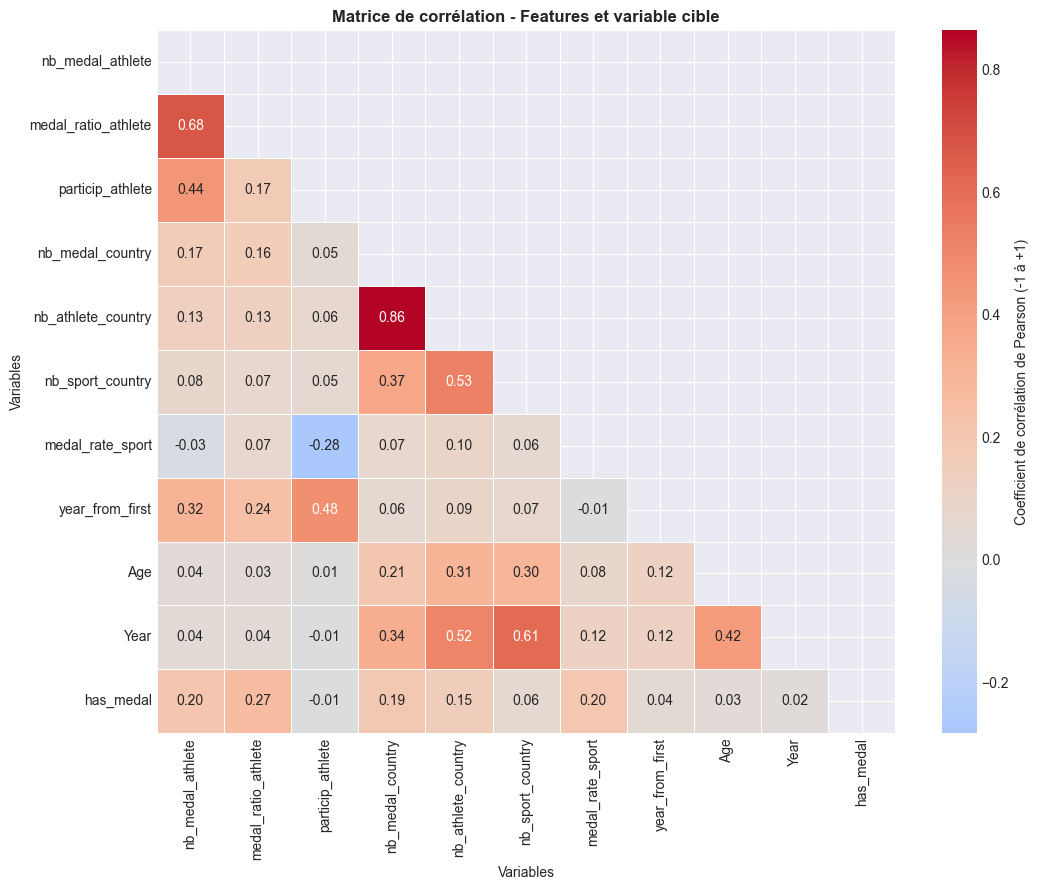

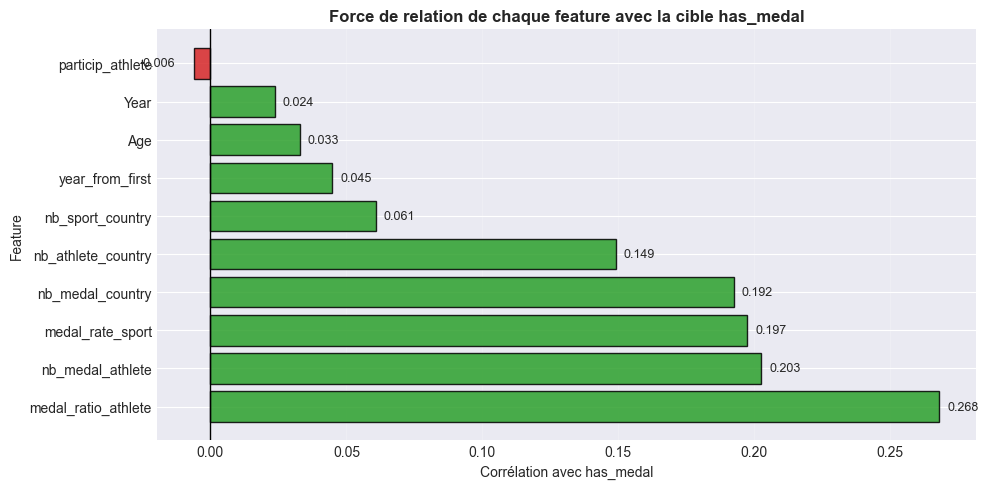

✓ Matrice + focus corrélation-cible affichés


In [37]:
# ======================================================================
# CELLULE D'ANALYSE DES FEATURES (stats + corrélations)
# Objectif: comprendre la structure des variables explicatives.
# ======================================================================

# 1) Définir explicitement les features numériques à inspecter.
feature_cols = [
    'nb_medal_athlete', 'medal_ratio_athlete', 'particip_athlete',
    'nb_medal_country', 'nb_athlete_country', 'nb_sport_country',
    'medal_rate_sport', 'year_from_first', 'Age', 'Year'
 ]

# 2) Afficher les statistiques descriptives de chaque feature.
#    Cela permet de détecter échelles, asymétries et valeurs extrêmes.
print("Statistiques des features:")
print(df[feature_cols].describe())

# ----------------------------------------------------------------------
# 3) Heatmap de corrélation complète
# ----------------------------------------------------------------------

# Créer une figure dédiée de taille confortable.
fig, ax = plt.subplots(figsize=(11, 9))

# Calculer la matrice de corrélation Pearson entre features et cible.
corr_matrix = df[feature_cols + ['has_medal']].corr()

# Créer un masque triangulaire pour éviter d'afficher deux fois l'info symétrique.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Tracer la heatmap annotée.
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    mask=mask,
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Coefficient de corrélation de Pearson (-1 à +1)'}
 )

# Habillage du graphique.
ax.set_title('Matrice de corrélation - Features et variable cible', fontsize=12, fontweight='bold')
ax.set_xlabel('Variables')
ax.set_ylabel('Variables')

# Ajustement + affichage.
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 4) Focus opérationnel: corrélation de chaque feature avec la cible
# ----------------------------------------------------------------------

# Extraire la colonne has_medal et retirer l'auto-corrélation parfaite.
target_corr = corr_matrix['has_medal'].drop('has_medal').sort_values(ascending=False)

# Créer une figure dédiée.
fig, ax = plt.subplots(figsize=(10, 5))

# Couleur verte si corrélation positive, rouge sinon.
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in target_corr.values]

# Tracer le barplot horizontal des corrélations à la cible.
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black', alpha=0.85)

# Habillage.
ax.set_title('Force de relation de chaque feature avec la cible has_medal', fontsize=12, fontweight='bold')
ax.set_xlabel('Corrélation avec has_medal')
ax.set_ylabel('Feature')

# Ajouter une ligne verticale à 0 pour distinguer visuellement positif/négatif.
ax.axvline(0, color='black', linewidth=1)

# Annoter chaque barre avec la valeur exacte.
for i, val in enumerate(target_corr.values):
    ax.text(val + (0.003 if val >= 0 else -0.02), i, f'{val:.3f}', va='center', fontsize=9)

# Grille légère sur l'axe des valeurs.
ax.grid(True, alpha=0.2, axis='x')

# Ajustement + affichage.
plt.tight_layout()
plt.show()

# Message final.
print("✓ Matrice + focus corrélation-cible affichés")

## 7. PRÉPARATION POUR MODÉLISATION

### 7.1 Sélection des variables et création des matrices X/y
On prépare les colonnes explicatives (features) et la cible binaire.
On traite aussi les valeurs manquantes pour rendre les matrices utilisables.

In [38]:
# 1) Définir explicitement les variables explicatives retenues pour le modèle
feature_cols = [
    'nb_medal_athlete', 'medal_ratio_athlete', 'particip_athlete',
    'nb_medal_country', 'nb_athlete_country', 'nb_sport_country',
    'medal_rate_sport', 'year_from_first', 'Age', 'Year'
]

# 2) Définir la cible binaire (0=non médaillé, 1=médaillé)
y = df['has_medal'].copy()

# 3) Construire la matrice X à partir des features sélectionnées
X = df[feature_cols].copy()

# 4) Imputer les valeurs manquantes de X avec la moyenne colonne par colonne
#    Cette stratégie simple évite la perte de lignes avant split
X = X.fillna(X.mean())

# 5) Afficher un contrôle rapide de cohérence dimensionnelle
print(f"Features: {feature_cols}")
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")

# 6) Afficher la distribution de classe pour anticiper le déséquilibre
print(f"\nDistribution target:")
print(f"  Non-médaillés: {(y == 0).sum()} ({(y == 0).mean():.2%})")
print(f"  Médaillés: {(y == 1).sum()} ({(y == 1).mean():.2%})")

# 7) Créer un split strictement temporel: passé -> train, récent -> test
train_mask = df['Year'] <= 2016
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

# 8) Vérifier la taille des jeux train/test
print(f"\nTrain/Test Split Temporel:")
print(f"  Train: {len(X_train)} samples (≤2016)")
print(f"  Test: {len(X_test)} samples (>2016)")
print(f"  Ratio: {len(X_train)/len(X):.2%} train / {len(X_test)/len(X):.2%} test")

# 9) Standardiser les variables numériques (fit sur train uniquement)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10) Confirmer la fin de la préparation
print(f"\n✓ Données préparées et normalisées")

Features: ['nb_medal_athlete', 'medal_ratio_athlete', 'particip_athlete', 'nb_medal_country', 'nb_athlete_country', 'nb_sport_country', 'medal_rate_sport', 'year_from_first', 'Age', 'Year']
Shape X: (196266, 10)
Shape y: (196266,)

Distribution target:
  Non-médaillés: 167991 (85.59%)
  Médaillés: 28275 (14.41%)

Train/Test Split Temporel:
  Train: 166254 samples (≤2016)
  Test: 30012 samples (>2016)
  Ratio: 84.71% train / 15.29% test

✓ Données préparées et normalisées


## 8. MODÈLE PRINCIPAL: XGBOOST

### 8.1 Entraînement du modèle XGBoost
On calcule un poids de classe pour gérer le déséquilibre.
Puis on entraîne le modèle et on produit les prédictions/probabilités.

In [39]:
# 1) Mesurer le ratio négatifs/positifs pour compenser le déséquilibre de classes
class_weight_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio de déséquilibre: {class_weight_ratio:.2f}")

# 2) Initialiser le modèle XGBoost avec des hyperparamètres conservateurs
print("\nEntraînement du modèle XGBoost...")
model = XGBClassifier(
    n_estimators=300,  # Nombre d'arbres
    max_depth=6,  # Profondeur max de chaque arbre
    learning_rate=0.05,  # Pas d'apprentissage (plus bas = plus stable)
    subsample=0.8,  # Sous-échantillonnage des lignes à chaque arbre
    colsample_bytree=0.8,  # Sous-échantillonnage des colonnes à chaque arbre
    scale_pos_weight=class_weight_ratio,  # Compensation de la classe minoritaire
    random_state=42,  # Reproductibilité
    n_jobs=-1,  # Utiliser tous les coeurs disponibles
    verbose=0
 )

# 3) Entraîner le modèle sur train et suivre le comportement sur test
model.fit(X_train_scaled, y_train, eval_set=[(X_test_scaled, y_test)], verbose=False)
print("✓ Modèle entraîné")

# 4) Générer prédictions de classes et probabilités pour train/test
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)
y_proba_train = model.predict_proba(X_train_scaled)[:, 1]
y_proba_test = model.predict_proba(X_test_scaled)[:, 1]

# 5) Calculer AUC train/test pour juger discrimination et généralisation
train_auc = roc_auc_score(y_train, y_proba_train)
test_auc = roc_auc_score(y_test, y_proba_test)

# 6) Reporter les métriques clés
print(f"\nRÉSULTATS:")
print(f"  Train AUC: {train_auc:.4f}")
print(f"  Test AUC: {test_auc:.4f}")
print(f"\n  Train Accuracy: {(y_pred_train == y_train).mean():.4f}")
print(f"  Test Accuracy: {(y_pred_test == y_test).mean():.4f}")

# 7) Afficher le détail précision/rappel/f1 sur le test
print(f"\n  Classification Report (Test):")
print(classification_report(y_test, y_pred_test, target_names=['Non-Médaillé', 'Médaillé']))

Ratio de déséquilibre: 6.06

Entraînement du modèle XGBoost...
✓ Modèle entraîné

RÉSULTATS:
  Train AUC: 0.8555
  Test AUC: 0.7461

  Train Accuracy: 0.7562
  Test Accuracy: 0.6648

  Classification Report (Test):
              precision    recall  f1-score   support

Non-Médaillé       0.92      0.66      0.77     25282
    Médaillé       0.28      0.71      0.40      4730

    accuracy                           0.66     30012
   macro avg       0.60      0.68      0.58     30012
weighted avg       0.82      0.66      0.71     30012



### Visualisations du modèle

### 8.2 Visualisation complète des performances
On analyse l'importance des variables, la confusion matrix, la ROC et la PR curve.
Ces vues permettent d'interpréter la qualité du modèle au-delà d'une seule métrique.

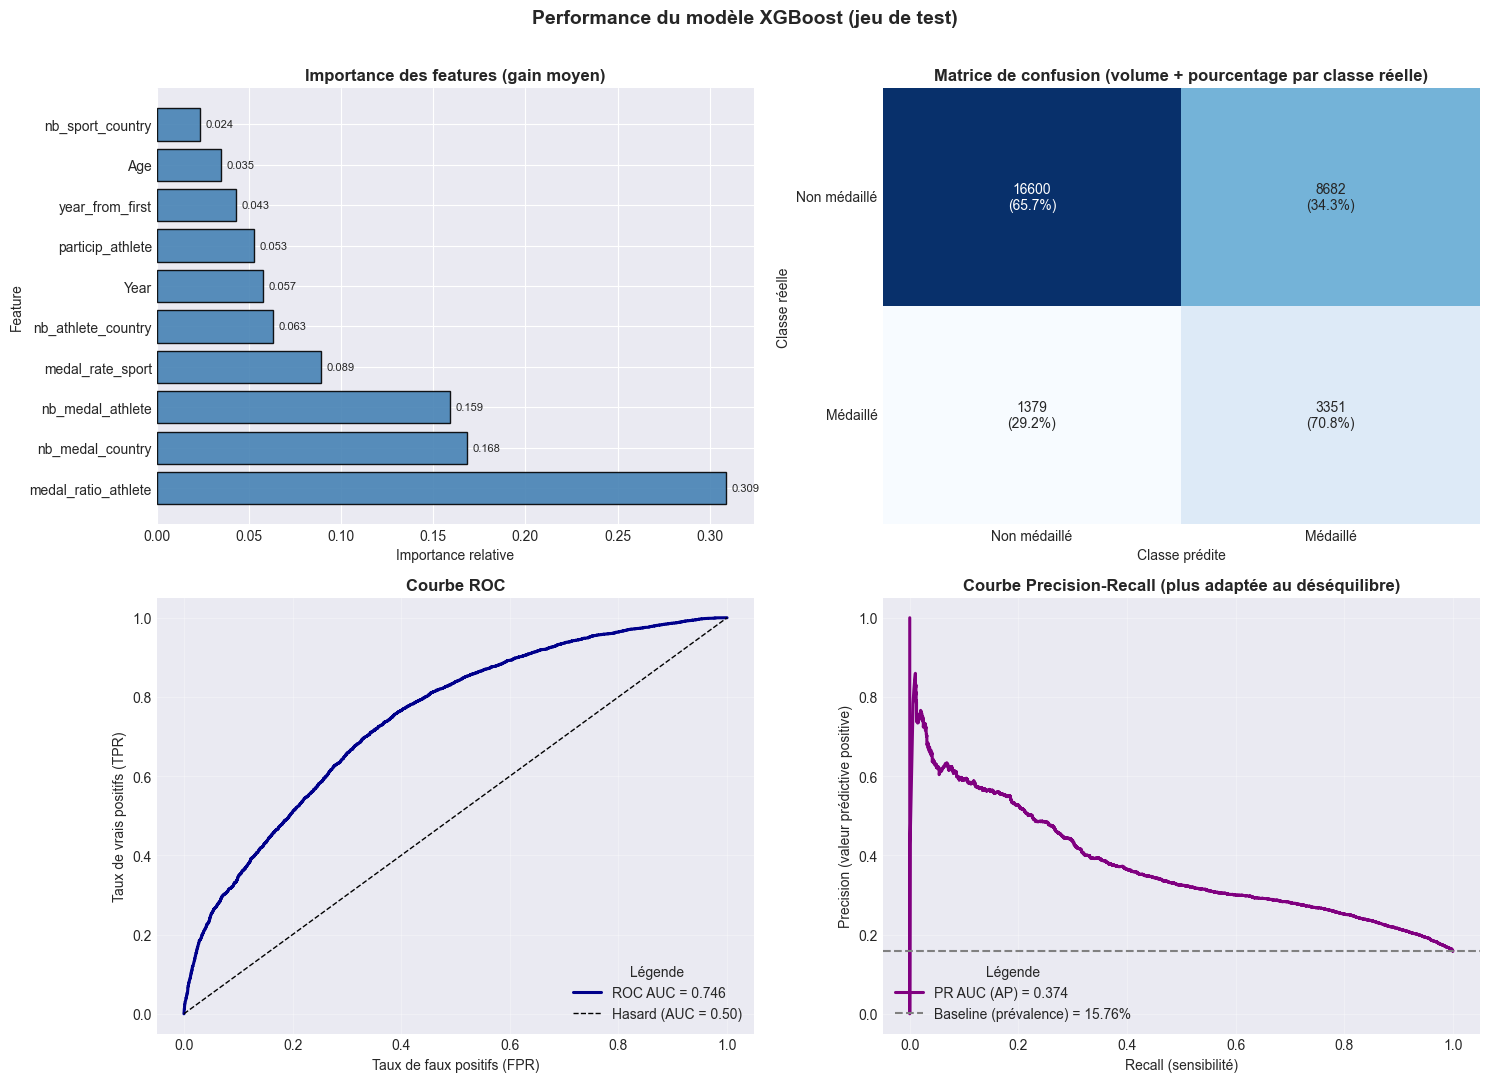

✓ Visualisations du modèle détaillées affichées


In [40]:
# ======================================================================
# CELLULE DE VISUALISATION PERFORMANCE MODÈLE (jeu de test)
# Objectif: lecture complète de la qualité du classifieur.
# ======================================================================

# 1) Créer une grille 2x2 pour concentrer les 4 vues clés.
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Performance du modèle XGBoost (jeu de test)", fontsize=14, fontweight='bold')

# ----------------------------------------------------------------------
# 2) Importance des features (contribution relative)
# ----------------------------------------------------------------------

# Construire une table triée des importances retournées par XGBoost.
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# Tracer un barplot horizontal (plus lisible pour les noms de variables).
axes[0, 0].barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color='steelblue',
    edgecolor='black',
    alpha=0.9
 )

# Habillage.
axes[0, 0].set_title('Importance des features (gain moyen)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Importance relative')
axes[0, 0].set_ylabel('Feature')

# Annoter chaque barre avec sa valeur numérique.
for i, val in enumerate(importance_df['Importance']):
    axes[0, 0].text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=8)

# ----------------------------------------------------------------------
# 3) Matrice de confusion enrichie (volume + taux par ligne)
# ----------------------------------------------------------------------

# Matrice brute des prédictions test.
cm = confusion_matrix(y_test, y_pred_test)

# Normalisation ligne par ligne (conditionnée à la classe réelle).
cm_norm = cm / cm.sum(axis=1, keepdims=True)

# Annotation mixte: valeur brute + pourcentage.
annot = np.array([[f"{cm[i, j]}\n({cm_norm[i, j]:.1%})" for j in range(cm.shape[1])] for i in range(cm.shape[0])])

# Heatmap de confusion.
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=axes[0, 1], cbar=False)

# Habillage.
axes[0, 1].set_title('Matrice de confusion (volume + pourcentage par classe réelle)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Classe réelle')
axes[0, 1].set_xlabel('Classe prédite')
axes[0, 1].set_xticklabels(['Non médaillé', 'Médaillé'])
axes[0, 1].set_yticklabels(['Non médaillé', 'Médaillé'], rotation=0)

# ----------------------------------------------------------------------
# 4) Courbe ROC
# ----------------------------------------------------------------------

# Calculer les points ROC à partir des probabilités test.
fpr, tpr, _ = roc_curve(y_test, y_proba_test)

# Tracer la courbe ROC du modèle.
axes[1, 0].plot(fpr, tpr, label=f'ROC AUC = {test_auc:.3f}', linewidth=2.2, color='darkblue')

# Tracer la diagonale aléatoire comme baseline.
axes[1, 0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Hasard (AUC = 0.50)')

# Habillage.
axes[1, 0].set_title('Courbe ROC', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Taux de faux positifs (FPR)')
axes[1, 0].set_ylabel('Taux de vrais positifs (TPR)')
axes[1, 0].legend(title='Légende', loc='lower right')
axes[1, 0].grid(True, alpha=0.3)

# ----------------------------------------------------------------------
# 5) Courbe Precision-Recall (plus informative en classes déséquilibrées)
# ----------------------------------------------------------------------

# Import local des métriques PR (garde la dépendance visible dans la cellule).
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculer les points PR + average precision (AP).
precision, recall, _ = precision_recall_curve(y_test, y_proba_test)
ap = average_precision_score(y_test, y_proba_test)

# Baseline PR = prévalence de la classe positive.
base_rate = y_test.mean()

# Tracer la courbe PR du modèle.
axes[1, 1].plot(recall, precision, color='purple', linewidth=2.2, label=f'PR AUC (AP) = {ap:.3f}')

# Tracer la baseline de prévalence.
axes[1, 1].axhline(base_rate, color='gray', linestyle='--', linewidth=1.5, label=f'Baseline (prévalence) = {base_rate:.2%}')

# Habillage.
axes[1, 1].set_title('Courbe Precision-Recall (plus adaptée au déséquilibre)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Recall (sensibilité)')
axes[1, 1].set_ylabel('Precision (valeur prédictive positive)')
axes[1, 1].legend(title='Légende', loc='lower left')
axes[1, 1].grid(True, alpha=0.3)

# 6) Ajuster la mise en page et afficher.
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Journal final.
print("✓ Visualisations du modèle détaillées affichées")

## 9. PRÉDICTIONS POUR JO 2028

### 9.1 Construction du pool d'athlètes JO 2028
On récupère la dernière observation de chaque athlète pour simuler son profil actuel.
Puis on applique des règles d'éligibilité (récence et âge projeté).

In [41]:
# Message de contexte pour la section de scoring JO 2028
print("Génération des prédictions pour JO 2028...\n")

# 1) Trier toutes les lignes par athlète puis par temps pour garantir un historique propre
sorted_df = df.sort_values(['Name', 'Year', 'player_id'])

# 2) Conserver uniquement la toute dernière observation connue de chaque athlète
#    Cela représente l'état le plus récent de chaque profil au moment de projeter JO 2028
pred_base = (
    sorted_df
    .groupby('Name', as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

# 3) Appliquer un filtre de récence sur les éditions olympiques les plus proches
recent_years = [2016, 2020, 2024]
pred_base = pred_base[pred_base['Year'].isin(recent_years)].copy()

# 4) Projeter l'âge en 2028 (âge observé + écart en années)
pred_base['projected_age_2028'] = pred_base['Age'] + (2028 - pred_base['Year'])

# 5) Filtrer les profils hors bornes d'âge retenues par le cadre métier
max_projected_age = 38
pred_base = pred_base[
    (pred_base['projected_age_2028'] >= 14) &
    (pred_base['projected_age_2028'] <= max_projected_age)
].copy()

# 6) Sécurité: si aucun athlète ne reste, on stoppe avec un message explicite
if pred_base.empty:
    raise ValueError("Aucun athlète éligible après filtres recence/age. Ajuster les critères.")

# 7) Afficher un résumé du pool final retenu pour les prédictions
print(f"✓ Pool éligible JO28: {len(pred_base)} athlètes")
print(f"  - JO récents autorisés: {recent_years}")
print(f"  - Âge projeté max en 2028: {max_projected_age}")

Génération des prédictions pour JO 2028...

✓ Pool éligible JO28: 25072 athlètes
  - JO récents autorisés: [2016, 2020, 2024]
  - Âge projeté max en 2028: 38


### 9.2 Scoring du pool avec le modèle entraîné
On prépare les features du pool, on applique le scaler puis on calcule les probabilités.
Ensuite, on calibre un seuil cohérent avec le taux historique.

In [42]:
# 1) Construire X_pred à partir des mêmes colonnes que pendant l'entraînement
X_pred = pred_base[feature_cols].copy()

# 2) Imputer les valeurs manquantes avec la moyenne globale des features d'apprentissage
#    On garde la même stratégie d'imputation pour rester cohérent entre train et prédiction
X_pred = X_pred.fillna(X.mean())

# 3) Appliquer exactement le scaler entraîné sur le train set
#    Important: on ne refit jamais ici pour éviter toute fuite de distribution
X_pred_scaled = scaler.transform(X_pred)

# 4) Produire la probabilité de la classe positive (médaillé = 1)
predictions = model.predict_proba(X_pred_scaled)[:, 1]

# 5) Calibrer un seuil dynamique basé sur le taux positif historique du train
#    target_rate représente la proportion de médaillés observée pendant l'entraînement
target_rate = y_train.mean()

# 6) Convertir ce taux cible en seuil de décision sur la distribution prédite
#    Exemple: si target_rate=20%, on retient les 20% plus fortes probabilités
decision_threshold = np.quantile(predictions, 1 - target_rate)

# 7) Binariser les probabilités avec le seuil calibré
predictions_binary = (predictions >= decision_threshold).astype(int)

### 9.3 Création du fichier final et top prédictions
On assemble les colonnes utiles pour le livrable business.
Enfin, on exporte en CSV puis on affiche le top des probabilités.

In [43]:
# 1) Construire la table résultat avec les colonnes business utiles à la lecture finale
results = pred_base[['Name', 'NOC', 'Sport', 'Sex', 'Age', 'Year', 'projected_age_2028']].copy()

# 2) Renommer l'année observée pour éviter l'ambiguïté avec l'année cible 2028
results = results.rename(columns={'Year': 'last_observed_year'})

# 3) Ajouter la probabilité de médaille et la décision binaire
results['jo28_medal_proba'] = predictions
results['jo28_prediction'] = predictions_binary

# 4) Exporter le livrable CSV dans le dossier de données nettoyées
output_path = os.path.join(clean_path, 'predictions_JO28.csv')
results.to_csv(output_path, index=False)

# 5) Journaliser les informations principales de sortie
print(f"✓ Prédictions sauvegardées: {output_path}")
print(f"  Nombre d'athlètes uniques prédits: {len(results)}")
print(f"  Seuil calibré: {decision_threshold:.3f} (cible historique: {target_rate:.2%})")

# 6) Afficher les 20 profils avec la probabilité la plus élevée
top_predictions = results.nlargest(20, 'jo28_medal_proba')
print("\nTop 20 athlètes prédits médaillés:")
print(
    top_predictions[
        ['Name', 'NOC', 'Sport', 'last_observed_year', 'projected_age_2028', 'jo28_medal_proba']
    ].to_string(index=False)
)

✓ Prédictions sauvegardées: ./data/data clean/predictions_JO28.csv
  Nombre d'athlètes uniques prédits: 25072
  Seuil calibré: 0.721 (cible historique: 14.16%)

Top 20 athlètes prédits médaillés:
             Name NOC                 Sport  last_observed_year  projected_age_2028  jo28_medal_proba
   Hannah Roberts USA Cycling BMX Freestyle                2024                30.0          0.988387
        Brian Irr USA                Karate                2020                34.0          0.985743
   Bubba Starling USA     Baseball/Softball                2020                34.0          0.985743
  David Robertson USA     Baseball/Softball                2020                34.0          0.985743
       Nick Bruce USA Cycling BMX Freestyle                2020                34.0          0.985743
   Sakura Kokumai USA                Karate                2020                34.0          0.985743
       van Hailey USA        3x3 Basketball                2024                30.0       

### Analyses des prédictions

### 9.4 Résumé chiffré des prédictions
Cette sous-partie présente les KPI principaux issus du scoring JO 2028.
On synthétise volume, taux prédits et principaux pays/sports concernés.

In [44]:
# 1) Afficher le bloc de synthèse chiffrée global
print("\nRÉSUMÉ DES PRÉDICTIONS JO 2028:")
print("\n  Statistiques:")

# 2) Indicateurs de volume et de performance prédite
print(f"    Total athlètes éligibles: {len(results)}")
print(f"    Médaillés prédits (p >= seuil calibré {decision_threshold:.3f}): {(results['jo28_prediction'] == 1).sum()}")
print(f"    Probabilité moyenne prédite: {results['jo28_medal_proba'].mean():.2%}")
print(f"    Taux prédit (après seuil calibré): {(results['jo28_prediction'] == 1).mean():.2%}")
print(f"    Années de dernière participation: {sorted(results['last_observed_year'].unique().tolist())}")
print(f"    Âge projeté 2028 (min/max): {results['projected_age_2028'].min():.1f} / {results['projected_age_2028'].max():.1f}")

# 3) Top pays par nombre de médaillés prédits
print("\n  Top 5 pays (par nombre de médailles prédites):")
country_medals = results[results['jo28_prediction'] == 1]['NOC'].value_counts().head(5)
for i, (country, count) in enumerate(country_medals.items(), 1):
    print(f"    {i}. {country}: {count} médailles")

# 4) Top sports par nombre de médaillés prédits
print("\n  Top 5 sports (par nombre de médailles prédites):")
sport_medals = results[results['jo28_prediction'] == 1]['Sport'].value_counts().head(5)
for i, (sport, count) in enumerate(sport_medals.items(), 1):
    print(f"    {i}. {sport}: {count} médailles")

# 5) Préparer un sous-ensemble dédié aux visualisations de la section suivante
pred_medalists = results[results['jo28_prediction'] == 1].copy()


RÉSUMÉ DES PRÉDICTIONS JO 2028:

  Statistiques:
    Total athlètes éligibles: 25072
    Médaillés prédits (p >= seuil calibré 0.721): 3553
    Probabilité moyenne prédite: 43.68%
    Taux prédit (après seuil calibré): 14.17%
    Années de dernière participation: [2016, 2020, 2024]
    Âge projeté 2028 (min/max): 20.0 / 38.0

  Top 5 pays (par nombre de médailles prédites):
    1. USA: 483 médailles
    2. AUS: 382 médailles
    3. JPN: 346 médailles
    4. FRA: 317 médailles
    5. GBR: 307 médailles

  Top 5 sports (par nombre de médailles prédites):
    1. Hockey: 376 médailles
    2. Handball: 277 médailles
    3. Rowing: 277 médailles
    4. Swimming: 233 médailles
    5. Basketball: 215 médailles


### 9.5 Visualisations détaillées des prédictions
On termine avec 4 graphiques: pays, distribution des probabilités, sexe et âge par sport.
Ces visuels rendent les résultats directement exploitables pour la présentation finale.

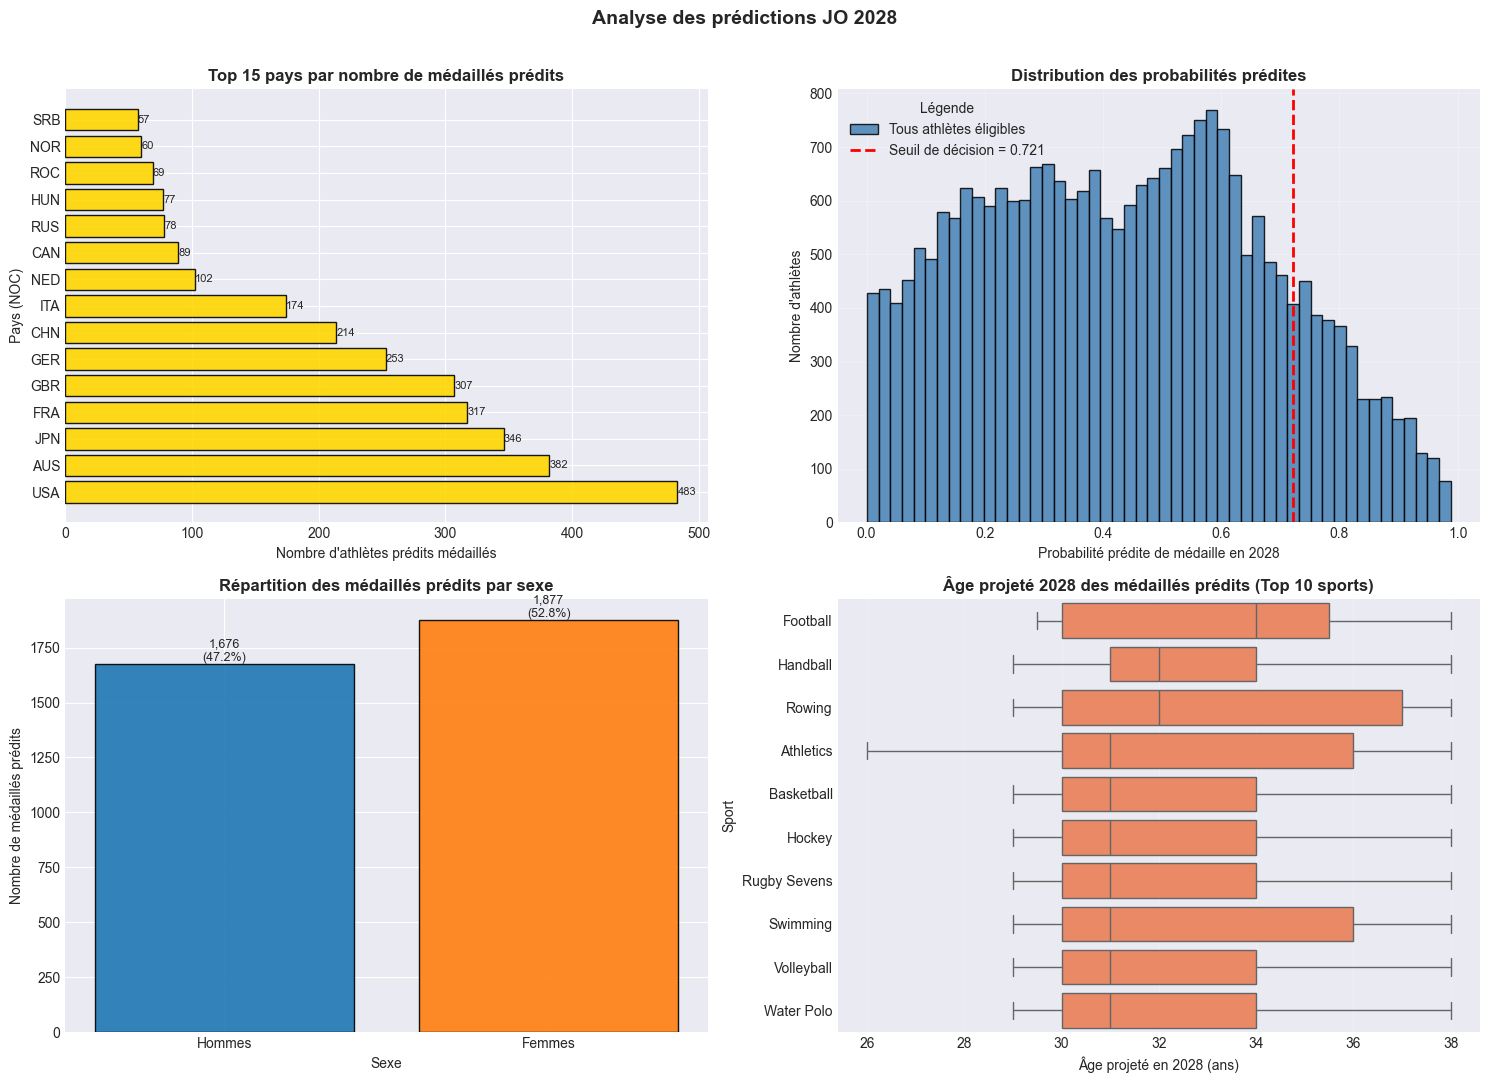


✓ Analyses de prédictions détaillées affichées


In [45]:
# ======================================================================
# CELLULE DE VISUALISATION PRÉDICTIONS JO 2028
# Objectif: transformer les scores modèle en insights métier lisibles.
# ======================================================================

# 1) Créer un canevas 2x2 pour rassembler les analyses finales.
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Analyse des prédictions JO 2028", fontsize=14, fontweight='bold')

# ----------------------------------------------------------------------
# 2) Top 15 pays en volume de médaillés prédits
# ----------------------------------------------------------------------

# Compter le nombre d'athlètes prédits médaillés par pays.
top_countries_pred = pred_medalists['NOC'].value_counts().head(15)

# Tracer un classement horizontal.
axes[0, 0].barh(
    top_countries_pred.index,
    top_countries_pred.values,
    color='gold',
    edgecolor='black',
    alpha=0.9
 )

# Habillage.
axes[0, 0].set_title('Top 15 pays par nombre de médaillés prédits', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Nombre d'athlètes prédits médaillés")
axes[0, 0].set_ylabel('Pays (NOC)')

# Annoter chaque barre avec le volume exact.
for i, v in enumerate(top_countries_pred.values):
    axes[0, 0].text(v + 0.2, i, str(v), va='center', fontsize=8)

# ----------------------------------------------------------------------
# 3) Distribution des probabilités + seuil de décision
# ----------------------------------------------------------------------

# Histogramme de toutes les probabilités produites pour JO 2028.
axes[0, 1].hist(
    results['jo28_medal_proba'],
    bins=50,
    color='steelblue',
    edgecolor='black',
    alpha=0.85,
    label='Tous athlètes éligibles'
 )

# Ligne verticale = seuil calibré utilisé pour passer en binaire.
axes[0, 1].axvline(
    decision_threshold,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Seuil de décision = {decision_threshold:.3f}'
 )

# Habillage.
axes[0, 1].set_title('Distribution des probabilités prédites', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Probabilité prédite de médaille en 2028')
axes[0, 1].set_ylabel("Nombre d'athlètes")
axes[0, 1].legend(title='Légende')
axes[0, 1].grid(True, alpha=0.25)

# ----------------------------------------------------------------------
# 4) Répartition des médaillés prédits par sexe
# ----------------------------------------------------------------------

# Compter les prédits médaillés par sexe (ordre imposé M puis F).
gender_pred = pred_medalists['Sex'].value_counts().reindex(['M', 'F']).dropna()

# Traduire les labels techniques en libellés lisibles.
gender_labels = ['Hommes' if s == 'M' else 'Femmes' for s in gender_pred.index]

# Tracer le barplot.
axes[1, 0].bar(
    gender_labels,
    gender_pred.values,
    color=['#1f77b4', '#ff7f0e'][:len(gender_pred)],
    edgecolor='black',
    alpha=0.9
 )

# Habillage.
axes[1, 0].set_title('Répartition des médaillés prédits par sexe', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Sexe')
axes[1, 0].set_ylabel('Nombre de médaillés prédits')

# Annoter avec volume + part relative.
for i, val in enumerate(gender_pred.values):
    pct = 100 * val / len(pred_medalists) if len(pred_medalists) else 0
    axes[1, 0].text(i, val, f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# ----------------------------------------------------------------------
# 5) Âge projeté par sport (boxplot sur Top 10 sports)
# ----------------------------------------------------------------------

# Identifier les sports les plus présents parmi les médaillés prédits.
top_sports = pred_medalists['Sport'].value_counts().head(10).index

# Restreindre les données à ces sports.
plot_df = pred_medalists[pred_medalists['Sport'].isin(top_sports)].copy()

# Ordonner les sports par médiane d'âge projeté (lecture plus informative).
order_sports = plot_df.groupby('Sport')['projected_age_2028'].median().sort_values(ascending=False).index

# Tracer le boxplot (dispersion + médiane + extrêmes).
sns.boxplot(
    data=plot_df,
    y='Sport',
    x='projected_age_2028',
    order=order_sports,
    ax=axes[1, 1],
    color='coral'
 )

# Habillage.
axes[1, 1].set_title('Âge projeté 2028 des médaillés prédits (Top 10 sports)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Âge projeté en 2028 (ans)')
axes[1, 1].set_ylabel('Sport')
axes[1, 1].grid(True, alpha=0.2, axis='x')

# 6) Ajuster la mise en page pour éviter les collisions de textes.
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Afficher la figure complète.
plt.show()

# Message de fin de section.
print("\n✓ Analyses de prédictions détaillées affichées")

---

##  RÉSUMÉ FINAL

### 10.1 Bilan automatique du pipeline
Cette cellule synthétise toutes les étapes exécutées et les métriques principales.
Elle sert de bloc de conclusion pour la restitution.

In [46]:
# En-tête visuel du résumé
print("\n" + "="*60)
print("JO 2028 - ML PIPELINE COMPLET")
print("="*60)

# Rappel des étapes réalisées
print("\nETAPES COMPLETEES:")
print("  ✓ Chargement et nettoyage des données")
print("  ✓ Analyses exploratoires (univariée, bivariée)")
print("  ✓ Feature engineering (10 features)")
print("  ✓ Train/Test split temporel")
print(f"  ✓ Entraînement XGBoost (ROC-AUC: {test_auc:.4f})")
print("  ✓ Génération des prédictions JO28")

# Récapitulatif du modèle
print("\nMODELE:")
print("  Algorithme: XGBoost Classifier")
print(f"  Train AUC: {train_auc:.4f}")
print(f"  Test AUC: {test_auc:.4f}")
print(f"  Features: {len(feature_cols)}")
print(f"  Train samples: {len(X_train)}")
print(f"  Test samples: {len(X_test)}")

# Récapitulatif des prédictions JO28
print("\nPREDICTIONS JO28:")
print(f"  Total éligibles: {len(results)} athlètes")
print("  Règle récence: participation 2016/2020/2024")
print("  Règle âge: âge projeté en 2028 <= 38")
print(f"  Seuil calibré: {decision_threshold:.3f}")
print(f"  Médaillés prédits: {(results['jo28_prediction'] == 1).sum()}")
print(f"  Taux prédit: {(results['jo28_prediction'] == 1).mean():.2%}")

# Instructions de suite
print("\nPROCHAINES ETAPES:")
print("  1. Utiliser predictions_JO28.csv dans le dashboard")
print("  2. Lancer: streamlit run app.py")
print("  3. Explorer les prédictions avec filtres interactifs")

# Pied de résumé
print("\n" + "="*60)
print("Pipeline ML complet et opérationnel")
print("="*60)


JO 2028 - ML PIPELINE COMPLET

ETAPES COMPLETEES:
  ✓ Chargement et nettoyage des données
  ✓ Analyses exploratoires (univariée, bivariée)
  ✓ Feature engineering (10 features)
  ✓ Train/Test split temporel
  ✓ Entraînement XGBoost (ROC-AUC: 0.7461)
  ✓ Génération des prédictions JO28

MODELE:
  Algorithme: XGBoost Classifier
  Train AUC: 0.8555
  Test AUC: 0.7461
  Features: 10
  Train samples: 166254
  Test samples: 30012

PREDICTIONS JO28:
  Total éligibles: 25072 athlètes
  Règle récence: participation 2016/2020/2024
  Règle âge: âge projeté en 2028 <= 38
  Seuil calibré: 0.721
  Médaillés prédits: 3553
  Taux prédit: 14.17%

PROCHAINES ETAPES:
  1. Utiliser predictions_JO28.csv dans le dashboard
  2. Lancer: streamlit run app.py
  3. Explorer les prédictions avec filtres interactifs

Pipeline ML complet et opérationnel


### 10.2 Lancement du dashboard Streamlit
Cette étape démarre l'interface de visualisation depuis le notebook.
Elle crée un processus local et affiche son PID pour le suivi.

In [47]:
# Importer les modules nécessaires au lancement du processus
import subprocess
import pathlib

# Définir le répertoire projet et le chemin de l'application Streamlit
project_root = pathlib.Path.cwd()
app_path = project_root / "app.py"

# Démarrer Streamlit en processus séparé
streamlit_process = subprocess.Popen(
    ["streamlit", "run", str(app_path)],
    cwd=str(project_root),
)

# Afficher les informations utiles
print("Dashboard lancé sur http://localhost:8501")
print(f"PID: {streamlit_process.pid}")

Dashboard lancé sur http://localhost:8501
PID: 1016


### 10.3 Arrêt propre du dashboard
Cette cellule vérifie si un processus Streamlit est actif.
Si oui, elle le termine proprement pour libérer le port local.

In [48]:
# Vérifier l'existence d'un processus Streamlit actif
if "streamlit_process" in globals() and streamlit_process.poll() is None:
    streamlit_process.terminate()  # Demande d'arrêt du processus
    print("Dashboard arrêté")
else:
    print("Aucun dashboard actif")

Dashboard arrêté
